# DS2000 & DS2001 Programming with Data & Practicum

# Project 3: Regression Inference

### 31 Points

## Due Friday, April 18, 10:00 PM

**Reading**: 
* [Chap 16 Inference for Regression](https://www.inferentialthinking.com/chapters/16/Inference_for_Regression.html)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell to load the provided tests. Each time you start your server, you will need to execute this cell again to load the tests.

For all problems that you must write our explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook! For example, if you use `max_temperature` in your answer to one question, do not reassign it later on.

**Note: This homework has hidden tests on it. That means even though tests may say 100% passed, it doesn't mean your final grade will be 100%. We will be running more tests for correctness once everyone turns in the homework.**

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore')
from datetime import datetime

import otter
grader = otter.Notebook("proj3.ipynb")

## An Introduction to Regression Inference

Previously in this class, we've used confidence intervals to quantify uncertainty about estimates. We can also run hypothesis tests using a confidence interval under the following procedure:

1. Define a null and alternative hypothesis (they must be of the form "The parameter is X" and "The parameter is not X").
2. Choose a p-value cutoff, and call it q.
3. Construct a $(100-q)\%$ interval using bootstrap sampling (for example, if your p-value cutoff q is 0.01, or 1%, then construct a 99% confidence interval).
4. Using the confidence interval, determine if your data are more consistent with your null or alternative hypothesis:
   * If the null hypothesis mean X is in your confidence interval, the data are more consistent with the null hypothesis.
   * If the null hypothesis mean X is *not* in your confidence interval, the data are more consistent with the alternative hypothesis.

More recently, we've discussed the use of linear regression to make predictions based on correlated variables. For example, we can predict the height of children based on the heights of their parents.

We can combine these two topics to make powerful statements about our population by using the following techniques:
- Bootstrapped interval for the true slope
- Bootstrapped prediction interval for y (given a particular value of x)

This project explores these two methods.

## The Data
The [Snowy Plover](https://www.audubon.org/field-guide/bird/snowy-plover) is a tiny bird that lives on the coast in parts of California and elsewhere. It is so small that it is vulnerable to many predators, including people and dogs that don't look where they are stepping when they go to the beach. It is considered endangered in many parts of the U.S.

The data are about the eggs and newly-hatched chicks of the Snowy Plover. Here's a picture of [a parent bird incubating its eggs](http://cescos.fau.edu/jay/eps/articles/snowyplover.html).

<img src="plover_and_eggs.jpeg" alt="Plover and Eggs">

The data were collected at the Point Reyes National Seashore by a former [student at UC Berkeley](https://openlibrary.org/books/OL2038693M/BLSS_the_Berkeley_interactive_statistical_system). The goal was to see how the size of an egg could be used to predict the weight of the resulting chick. The bigger the newly-hatched chick, the more likely it is to survive.

<img src="plover_and_chick.jpeg" alt="Plover and Chick">

Each row of the data frame below corresponds to one Snowy Plover egg and the resulting chick. Note how tiny the bird is:

- `Egg Length` and `Egg Breadth` (widest diameter) are measured in millimeters
- `Egg Weight` and `Bird Weight` are measured in grams; for comparison, a standard paper clip weighs about one gram

In [2]:
birds = Table.read_table('snowy_plover.csv')
birds

Egg Length,Egg Breadth,Egg Weight,Bird Weight
28.8,21.84,7.4,5.2
29.04,22.45,7.7,5.4
29.36,22.48,7.9,5.6
30.1,21.71,7.5,5.3
30.17,22.75,8.3,5.9
30.34,22.84,8.5,5.8
30.36,22.5,8.2,5.8
30.46,22.72,8.3,6
30.54,23.31,9,6.1
30.62,22.94,8.5,6.2


In this investigation, we will be using the egg weight to predict bird weight. Run the cell below to create a scatter plot of the egg weights and bird weights, along with their line of best fit.

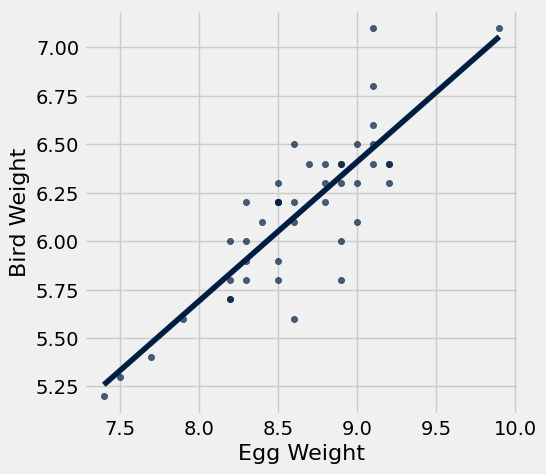

In [3]:
# Just run this cell and examine the scatter plot.
birds.scatter('Egg Weight', "Bird Weight", fit_line=True)

## 1. Finding the Bootstrap Confidence Interval for the True Slope

Looking at the scatter plot of our sample, we observe a linear relationship between egg weight and bird weight. However, relationships that appear in a sample might not exist in the population from which the sample was taken.

We want to know if there truly exists a linear relationship between egg weight and bird weight for Snowy Plovers. If there is no linear relationship between the two variables, then we'd expect a correlation of 0. Consequently, the slope of the regression line would also be 0. 

**Question 1.1.** Let's run a hypothesis test using confidence intervals to see if there is a linear relationship between egg weight and bird weight. Define the null and alternative hypotheses that will allow you to conduct this test. **(8 points)**

*Note:* Please write your answer **in the cell below** in the following format:
- **Null Hypothesis:**
- **Alternative Hypothesis:**

Null Hypothesis: There does not exist a linear relationship between egg weight an bird weight in the Snowy Plover population (the slope of the true line is zero). Any samples reflecting a linear relationship are simply due to chance.

Alternative Hypothesis: There is a linear relationship between egg weight an bird weight in the Snowy Plover population.

**Question 1.2. (3 pts)** Define the following two functions:

1. `standard_units`: This function takes in an array of numbers and returns an array containing those numbers converted to standard units.
2. `correlation`: This function takes in a table and two column names (one for *x* and one for *y*) and returns the correlation between these columns. 

In [4]:
def standard_units(arr):
    return (arr-np.average(arr))/np.std(arr)

def correlation(tbl, x_col, y_col):
    x_su = standard_units(tbl.column(x_col))
    y_su = standard_units(tbl.column(y_col))
    return np.average(x_su*y_su)

In [5]:
grader.check("q1_2")

q1_2 results: All test cases passed!

**Question 1.3. (4 pts)** Using the functions you just implemented, create a function called `fit_line`.  It should take a table like `birds` and the column names associated to *x* and *y* as its arguments and return an array containing the slope and intercept of the regression line (in that order) that predicts the *y* column in the table using the *x* column.

In [6]:
def fit_line(tbl, x_col, y_col):
    x_sd = np.std(tbl.column(x_col))
    y_sd = np.std(tbl.column(y_col))
    r = correlation(tbl, x_col, y_col)
    slope = r*(y_sd/x_sd)
    x_mean = np.average(tbl.column(x_col))
    y_mean = np.average(tbl.column(y_col))
    intercept = y_mean - slope*x_mean
    return make_array(slope, intercept)
   
                       
fit_line(birds, "Egg Weight", "Bird Weight")

array([ 0.71851534, -0.05827226])

In [7]:
grader.check("q1_3")

q1_3 results: All test cases passed!

Run this cell to plot the line produced by calling `fit_line` on the `birds` table.  

**Note:** You are not responsible for the code in the cell below, but make sure that your `fit_line` function generated a reasonable line for the data.

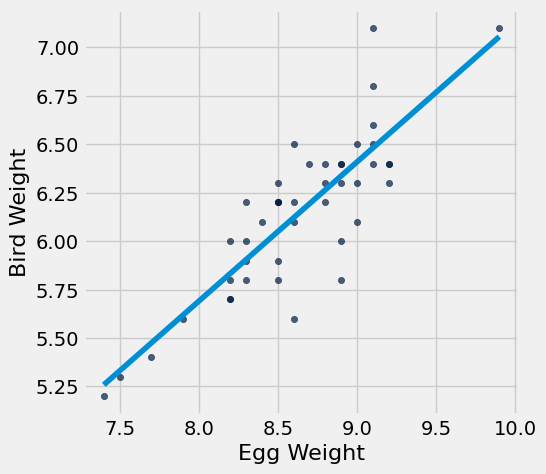

In [8]:
# Ensure your fit_line function fits a reasonable line 
# to the data in birds, using the plot below.

slope, intercept = fit_line(birds, "Egg Weight", "Bird Weight")
birds.scatter("Egg Weight", "Bird Weight")
plt.plot([min(birds.column("Egg Weight")), max(birds.column("Egg Weight"))], 
         [slope*min(birds.column("Egg Weight"))+intercept, slope*max(birds.column("Egg Weight"))+intercept])
plt.show()

Now we have all the tools we need to create a confidence interval that quantifies our uncertainty about the true relationship between egg weight and bird weight.

**Question 1.4. (4 pts)** Create an array called `resampled_slopes` that contains the slope of the best fit line for 1000 bootstrap resamples of `birds`. Plot the distribution of these slopes.


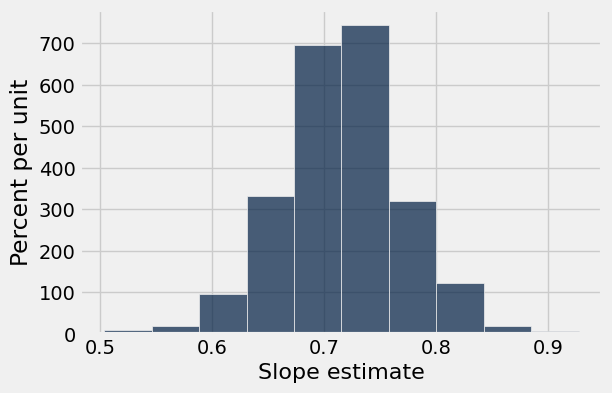

In [9]:
resample_slopes = make_array()

for i in np.arange(1000): 
    birds_resample = birds.sample()
    resample_line = fit_line(birds_resample, "Egg Weight", "Bird Weight")
    resample_slope = resample_line.item(0)
    resample_slopes = np.append(resample_slopes, resample_slope)
    
# DO NOT CHANGE THIS LINE
Table().with_column("Slope estimate", resample_slopes).hist()

In [10]:
grader.check("q1_4")

q1_4 results: All test cases passed!

**Question 1.5. (2 pts)** Use your resampled slopes to construct an 95% confidence interval for the true value of the slope. **

In [11]:
lower_end = percentile(2.5, resample_slopes)
upper_end = percentile(97.5, resample_slopes)
print("95% confidence interval for slope: [{:g}, {:g}]".format(lower_end, upper_end))

95% confidence interval for slope: [0.606305, 0.823638]


In [12]:
grader.check("q1_5")

q1_5 results: All test cases passed!

**Question 1.6. (3 pts)** Based on your confidence interval, would you accept or reject the null hypothesis that the true slope is 0?  Why?  What p-value cutoff are you using?

Based on the confidence interval, I would reject the null hypothesis that the true slope is 0. Based on the 95% confidence interval for the slope, 0 does not fall within the range, and therefore supports the alternative hypothesis. The p-value cutoff being used is 5% because this is a 95% confidence interval.

<!-- END QUESTION -->



## 2. Finding the Bootstrap Prediction Interval

Suppose we're visiting Point Reyes and stumble upon some Snowy Plover eggs; we'd like to know how heavy they'll be once they hatch. In other words, we want to use our regression line to make predictions about a bird's weight based on the weight of the corresponding egg.

However, just as we're uncertain about the slope of the true regression line, we're also uncertain about the predictions made based on the true regression line.

**Question 2.1. (4 pts)** Define the function `fitted_value`.  It should take in four arguments:

1. `table`: a table like `birds`.  We'll be predicting the values in the second column using the first.
2. `x_col`: the name of our x-column within the input `table`
3. `y_col`: the name of our y-column within the input `table`
2. `given_x`: a number, the value of the predictor variable for which we'd like to make a prediction.
  
The function should return the line’s prediction for the given x.

In [13]:
def fitted_value(table, x_col, y_col, given_x):
    line = fit_line(table, x_col, y_col)
    slope = line.item(0)
    intercept = line.item(1)
    return given_x*slope + intercept

# Here's an example of how fitted_value is used. The code below
# computes the prediction for the bird weight, in grams, based on
# an egg weight of 8 grams.
egg_weight_eight = fitted_value(birds, "Egg Weight", "Bird Weight", 8)
egg_weight_eight

5.689850497215146

In [14]:
grader.check("q2_1")

q2_1 results: All test cases passed!

**Question 2.2. (1 pt)** Shayan, the resident Snowy Plover expert at Point Reyes, tells us that the egg he has been carefully observing has a weight of 9 grams. Using `fitted_value` above, assign the variable `experts_egg` to the predicted bird weight for Shayan's egg. 

In [15]:
experts_egg = fitted_value(birds, "Egg Weight", "Bird Weight", 9)
experts_egg

6.408365842108825

In [16]:
grader.check("q2_2")

q2_2 results: All test cases passed!

In [17]:
# Let's look at the number of rows in the birds table.
birds.num_rows

44

A fellow parkgoer raises the following objection to your prediction:

> "Your prediction depends on your sample of 44 birds.  Wouldn't your prediction change if you had a different sample of birds?"

Having read section [16.3](https://inferentialthinking.com/chapters/16/3/Prediction_Intervals.html) of the textbook, you know just the response! Had the sample been different, the regression line would have been different too. This would ultimately result in a different prediction. To see how good our prediction is, we must get a sense of how variable the prediction can be.

**Question 2.3. (3 pts)** Define a function `compute_resampled_line` that takes in a table `tbl`and two column names, `x_col` and `y_col`, and returns an array containing the parameters of the best fit line (slope and intercept) for one bootstrapped resample of the table.

In [18]:
def compute_resampled_line(tbl, x_col, y_col):
    resample = tbl.sample()
    resampled_line = fit_line(resample, x_col, y_col)
    return resampled_line

In [19]:
grader.check("q2_3")

q2_3 results: All test cases passed!

**Run** the following cell below in order to define the function `bootstrap_lines`.  It takes in four arguments:
1. `tbl`: a table like `birds`
2. `x_col`: the name of our x-column within the input `tbl`
3. `y_col`: the name of our y-column within the input `tbl`
4. `num_bootstraps`: an integer, a number of bootstraps to run.

It returns a *table* with one row for each bootstrap resample and the following two columns:
1. `Slope`: the bootstrapped slopes 
2. `Intercept`: the corresponding bootstrapped intercepts 

In [20]:
def bootstrap_lines(tbl, x_col, y_col, num_bootstraps):
    resampled_slopes = make_array()
    resampled_intercepts = make_array() 
    for i in np.arange(num_bootstraps): 
        resampled_line = compute_resampled_line(tbl, x_col, y_col) 
        resampled_slope = resampled_line.item(0) 
        resampled_intercept = resampled_line.item(1) 
        resampled_slopes = np.append(resampled_slopes,resampled_slope)
        resampled_intercepts = np.append(resampled_intercepts,resampled_intercept)
    tbl_lines = Table().with_columns('Slope', resampled_slopes, 'Intercept', resampled_intercepts)
    return tbl_lines

regression_lines = bootstrap_lines(birds, "Egg Weight", "Bird Weight", 1000)
regression_lines

Slope,Intercept
0.75275,-0.344615
0.716083,-0.0301423
0.70462,0.0584383
0.713058,0.0330578
0.669126,0.365534
0.724106,-0.110065
0.718799,-0.0544743
0.809839,-0.803588
0.771308,-0.506994
0.708504,0.0585545


**Question 2.4. (2 pts)** Create an array called `predictions_for_eight` that contains the predicted bird weights based on an egg of weight 8 grams for each regression line in `regression_lines`. 

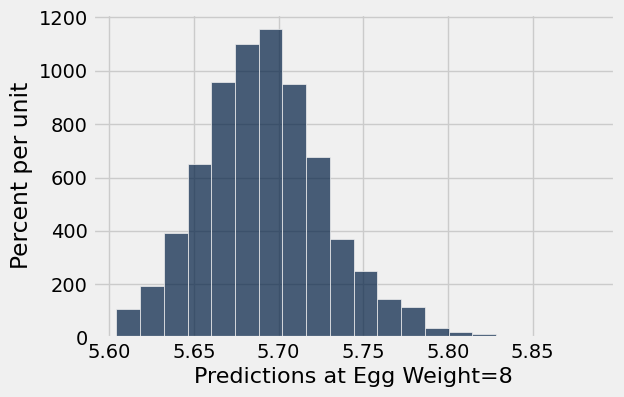

In [21]:
predictions_for_eight = regression_lines.column(0)*(8) + regression_lines.column(1)

# This will make a histogram of your predictions:
table_of_predictions = Table().with_column('Predictions at Egg Weight=8', predictions_for_eight)
table_of_predictions.hist('Predictions at Egg Weight=8', bins=20)

In [22]:
grader.check("q2_4")

q2_4 results: All test cases passed!

**Question 2.5. (2 pts)** Create an approximate 95% confidence interval for these predictions. 

In [23]:
lower_bound = percentile(2.5, predictions_for_eight)
upper_bound = percentile(97.5, predictions_for_eight)

print('95% Confidence interval for predictions for x=8: (', lower_bound,",", upper_bound, ')')

95% Confidence interval for predictions for x=8: ( 5.62239407906 , 5.77775209577 )


In [24]:
grader.check("q2_5")

q2_5 results: All test cases passed!

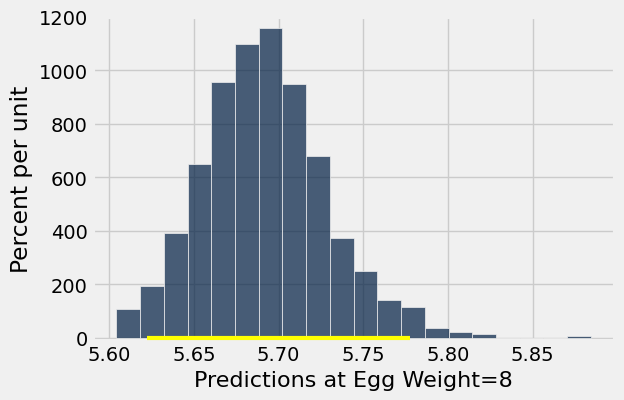

In [25]:
# This will make a histogram and add the confidence interval of your predictions:
table_of_predictions.hist('Predictions at Egg Weight=8', bins=20)
plt.ylim(-0.1, 12)
plt.plot(make_array(lower_bound, upper_bound), make_array(0, 0), color='yellow', lw=3, zorder=5);

**Congratulations!  You've completed Project 3!**

Please save your notebook, download a pdf version of the notebook, and submit it to Gradescope.

If you haven't done so, you may want to save/download **all your work** from this course in your own computer.  To do so, go to ood.discovery.neu.edu *Dashboard (or Home)*.
Instead of *Courses* or *My Interactive Sessions*, select *Files > Home Directory*. The contents of your home directory is displayed. To download a file/folder to your hard drive, navigate to the file/folder you want to download, select the file/folder, and click Download. If prompted by your browser, click OK to save your file to your hard drive.